In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [2]:
pd.set_option("display.max_columns",20)
pd.set_option("display.width",120)

In [10]:
print("="*70)
print("raw data loading")
print("="*70)
df_raw=pd.read_csv(r"C:\Users\Admin\Desktop\PROJECTS\descriptive statistics\fitness_messy.csv")
print(f"shape,{df_raw.shape}")
print(f"dtypes:{df_raw.dtypes.value_counts()}")
print(f"duplicate rows {df_raw.duplicated().sum()}")
JUNK = ["N/A", "unknown", "error", "--", "null", "NaN", "?", "nan", ""]
print(f"\nColumns with junk string values:")
for col in df_raw.columns:
    junk_count = df_raw[col].astype(str).isin(JUNK).sum()
    if junk_count > 0:
        print(f"  {col:<30} {junk_count} junk entries")


raw data loading
shape,(515, 54)
dtypes:str        32
float64    21
int64       1
Name: count, dtype: int64
duplicate rows 9

Columns with junk string values:
  age                            2 junk entries
  steps                          1 junk entries
  calories_burned                3 junk entries
  calories_consumed              1 junk entries
  sleep_hours                    1 junk entries
  sleep_quality_score            3 junk entries
  active_minutes                 1 junk entries
  bmi                            2 junk entries
  body_fat_pct                   3 junk entries
  stress_level                   1 junk entries
  hrv_ms                         2 junk entries
  systolic_bp                    1 junk entries
  diastolic_bp                   3 junk entries
  respiratory_rate               3 junk entries
  workout_intensity              1 junk entries
  distance_km                    5 junk entries
  running_pace_min_km            2 junk entries
  cycling_km             

In [19]:
#SECTION 2: DATA CLEANING
print("="*70)
print("data cleaning")
print("="*70)

df=df_raw.copy()
 #step1. remove null values
df.replace(JUNK,np.nan,inplace=True)

#step 2. drop duplicates
df.drop_duplicates(inplace=True)

#step3. defining categorical and numeric columns
categ_cols=['gender','activity_level','diet_type']
numer_cols=[c for c in df.columns if c not in categ_cols + ['user_id']]

#step4. force numeric columns to numeric values
df[numer_cols]=df[numer_cols].apply(pd.to_numeric, errors="coerce")

#step5. standardise column names
df["gender"]=df["gender"].str.strip().str.title()
df["activity_level"]=df["activity_level"].str.strip().str.replace("E","e",regex=False).str.title()
df["diet_type"]=df["diet_type"].str.strip().str.title()

#step6. clipping outliers using 1st and 99th percentile
for col in numer_cols:
    p01=df[col].quantile(0.01)
    p99=df[col].quantile(0.99)
    to_clip=((df[col]<p01) | (df[col]>p99)).sum()
    if to_clip>0:
        df[col]=df[col].clip(lower=p01, upper=p99)

#step7. fill null values
for col in numer_cols:
    df[col]=df[col].fillna(df[col].median())
for ct in categ_cols:
    df[ct]=df[ct].fillna(df[ct].mode()[0])

data cleaning


In [20]:
print("\n" + "=" * 70)
print("SECTION 3 — FULL DESCRIPTIVE STATS (df.describe)")
print("=" * 70)

summary = df[numer_cols].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).T
summary["skew"]  = df[numer_cols].skew()
summary["kurt"]  = df[numer_cols].kurt()
summary["cv%"]   = (df[numer_cols].std() / df[numer_cols].mean() * 100).round(1)  # coefficient of variation
print(summary.round(2).to_string())
print("\ncv% = Coefficient of Variation (std/mean × 100) — higher = more spread relative to mean")



SECTION 3 — FULL DESCRIPTIVE STATS (df.describe)
                        count     mean      std      min      10%      25%       50%       75%       90%       max  skew  kurt   cv%
age                     506.0    45.57    16.34    18.00    23.00    32.25     45.00     60.00     69.00     75.00  0.06 -1.06  35.9
weight_kg               506.0    86.95    23.15    46.00    54.55    68.30     86.50    105.65    120.20    129.14  0.04 -0.99  26.6
height_cm               506.0   174.89    13.90   150.66   155.75   163.12    175.00    186.20    194.55    199.63  0.04 -1.05   7.9
steps                   506.0  9838.44  4795.11   694.45  2992.00  5818.50  10124.50  13820.50  16438.50  17759.60 -0.14 -1.00  48.7
calories_burned         506.0   535.83   209.60   156.61   238.00   371.25    519.50    710.75    837.50    895.00  0.01 -1.03  39.1
calories_consumed       506.0  2325.97   654.25  1213.50  1409.00  1772.25   2311.00   2892.00   3245.00   3489.00  0.03 -1.11  28.1
sleep_hours        

In [26]:
#section 4- Z scores and Standardisation
print("="*70)
print("SECTION 4 — Z-SCORES")
print("=" * 70)

#z score is calc only for numeric columns.
#informs about how many std deviations away is our data point from the mean
z_scores=df[numer_cols].apply(stats.zscore)
print("|z|>3 implies extreme value\n")

#flag users with extreme z scores on key health attributes
KEY=["bmi","resting_heart_rate","blood_glucose","systolic_bp","vo2_max"]
for col in KEY:
    extremes=df[np.abs(z_scores[col]>1.5)][["user_id",col]].copy()
    extremes["z_score"]=z_scores.loc[extremes.index,col].round(2)
    if not extremes.empty:
        print(f"{col} — {len(extremes)} users with |z| > 1.5:")
        print(extremes.to_string(index=False))
        print()


SECTION 4 — Z-SCORES
|z|>3 implies extreme value

bmi — 42 users with |z| > 1.5:
 user_id  bmi  z_score
      28 41.8     1.80
      43 41.2     1.72
      48 40.6     1.64
      52 40.6     1.64
      54 41.0     1.70
      62 41.4     1.75
      76 40.9     1.68
      91 41.3     1.74
     114 40.0     1.56
     117 39.8     1.54
     157 41.8     1.80
     170 40.8     1.67
     194 41.8     1.80
     202 40.8     1.67
     220 40.9     1.68
     221 41.8     1.80
     229 41.1     1.71
     233 40.6     1.64
     261 41.7     1.79
     270 40.9     1.68
     289 41.2     1.72
     295 41.5     1.76
     300 40.3     1.60
     303 40.2     1.59
     304 39.9     1.55
     317 40.2     1.59
     332 41.7     1.79
     342 40.5     1.63
     353 41.7     1.79
     382 40.5     1.63
     384 41.5     1.76
     391 41.6     1.78
     413 39.6     1.51
     422 39.9     1.55
     426 41.0     1.70
     430 40.5     1.63
     444 41.1     1.71
     448 41.8     1.80
     458 41.5     1.76

In [28]:
#section 5. Grouped Analysis
print("\n" + "=" * 70)
print("SECTION 5 — GROUPED ANALYSIS")
print("=" * 70)

GROUP_STATS=["steps","calories_burned","sleep_hours","resting_heart_rate","bmi","vo2_max","stress_level"]

#1 by activity level
print("\n--- Mean stats by Activity Level ---")
act_group=df.groupby('activity_level')[GROUP_STATS].mean().round(1)
print(act_group.to_string())

#2 by gender
print("\n--- Mean stats by Gender ---")
gender_group=df.groupby('gender')[GROUP_STATS].mean().round(1)
print(gender_group.to_string())

#3 by diet_type
print("\n--- Mean BMI and calories_burned by Diet Type ---")
diet_group = df.groupby("diet_type")[["bmi", "calories_burned", "protein_g"]].mean().round(1)
print(diet_group.to_string())

#4 by age bands
df["age_band"] = pd.cut(df["age"], bins=[17, 29, 39, 49, 59, 75],
                         labels=["18-29", "30-39", "40-49", "50-59", "60+"])
print("\n--- Mean stats by Age Band ---")
age_group = df.groupby("age_band")[GROUP_STATS].mean().round(1)
print(age_group.to_string())



SECTION 5 — GROUPED ANALYSIS

--- Mean stats by Activity Level ---
                  steps  calories_burned  sleep_hours  resting_heart_rate   bmi  vo2_max  stress_level
activity_level                                                                                        
Active           9654.6            515.1          6.9                79.0  28.1     42.9           5.6
Light           10338.1            522.6          6.7                77.3  27.5     43.1           5.5
Moderate         8827.5            552.4          7.2                79.4  29.4     41.6           5.8
Sedentary       10066.9            532.1          6.9                78.6  28.9     40.5           4.9
Very Active     10333.7            555.7          7.0                78.2  27.7     42.4           5.2

--- Mean stats by Gender ---
         steps  calories_burned  sleep_hours  resting_heart_rate   bmi  vo2_max  stress_level
gender                                                                                 

In [31]:
print("\n" + "=" * 70)
print("SECTION 6 — TOP CORRELATIONS")
print("=" * 70)

corr_matrix = df[numer_cols].corr()

# Extract upper triangle, sort by absolute value
corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                          .stack()
                          .reset_index())
corr_pairs.columns = ["var1", "var2", "r"]
corr_pairs["abs_r"] = corr_pairs["r"].abs()
top_corr = corr_pairs.sort_values("abs_r", ascending=False).head(20)

print("\nTop 20 strongest correlations:")
print(top_corr[["var1", "var2", "r"]].to_string(index=False))


SECTION 6 — TOP CORRELATIONS

Top 20 strongest correlations:
               var1                 var2         r
       body_fat_pct       recovery_score  0.148331
     max_heart_rate workout_duration_min  0.138119
sleep_quality_score     outdoor_time_min -0.129974
   respiratory_rate            protein_g -0.128908
              steps       floors_climbed -0.125918
sleep_quality_score       active_minutes -0.125822
      swimming_laps                fat_g  0.121619
           spo2_pct       floors_climbed -0.119338
sleep_quality_score        swimming_laps -0.117229
    calories_burned      caffeine_mg_day  0.116808
   respiratory_rate    flexibility_score  0.116579
          weight_kg       muscle_mass_kg  0.116248
        distance_km       strength_score  0.115792
running_pace_min_km              fiber_g  0.113550
    calories_burned       max_heart_rate -0.113371
       body_fat_pct        blood_glucose -0.112683
sleep_quality_score    screen_time_hours -0.110704
       stress_level 


SECTION 7 — GENERATING VISUALIZATIONS ...


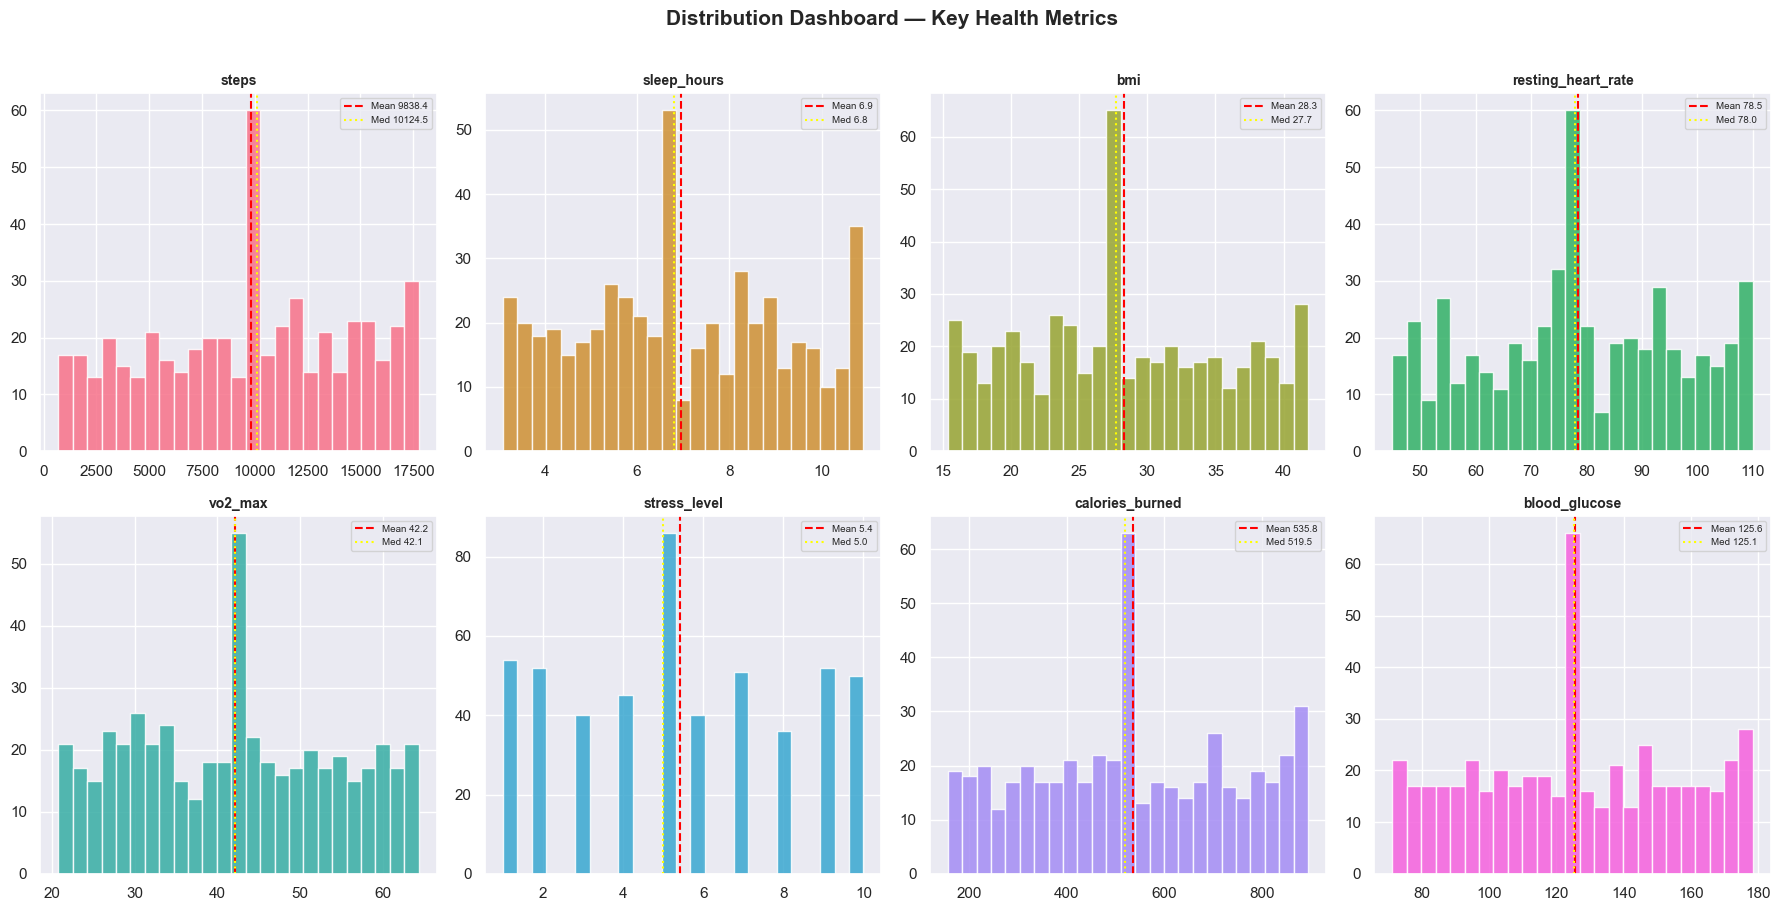

Saved: plot_1_distributions.png


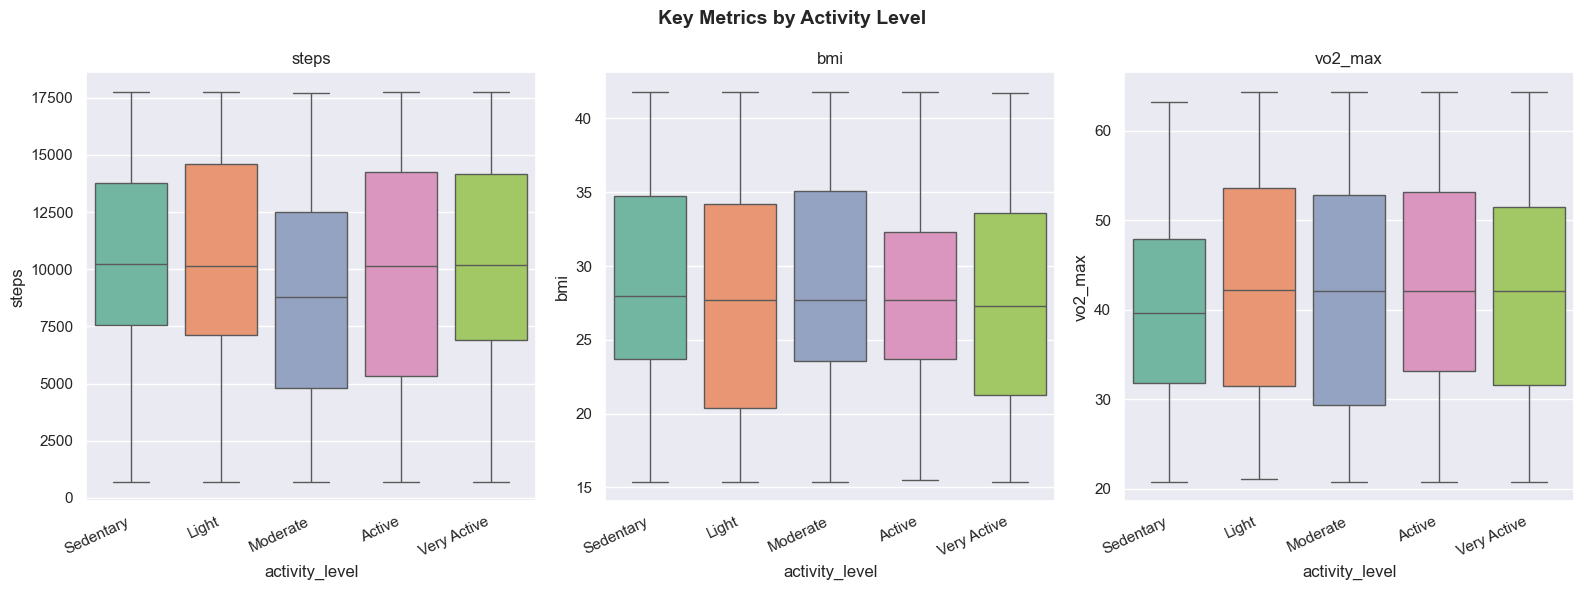

Saved: plot_2_activity_boxplots.png


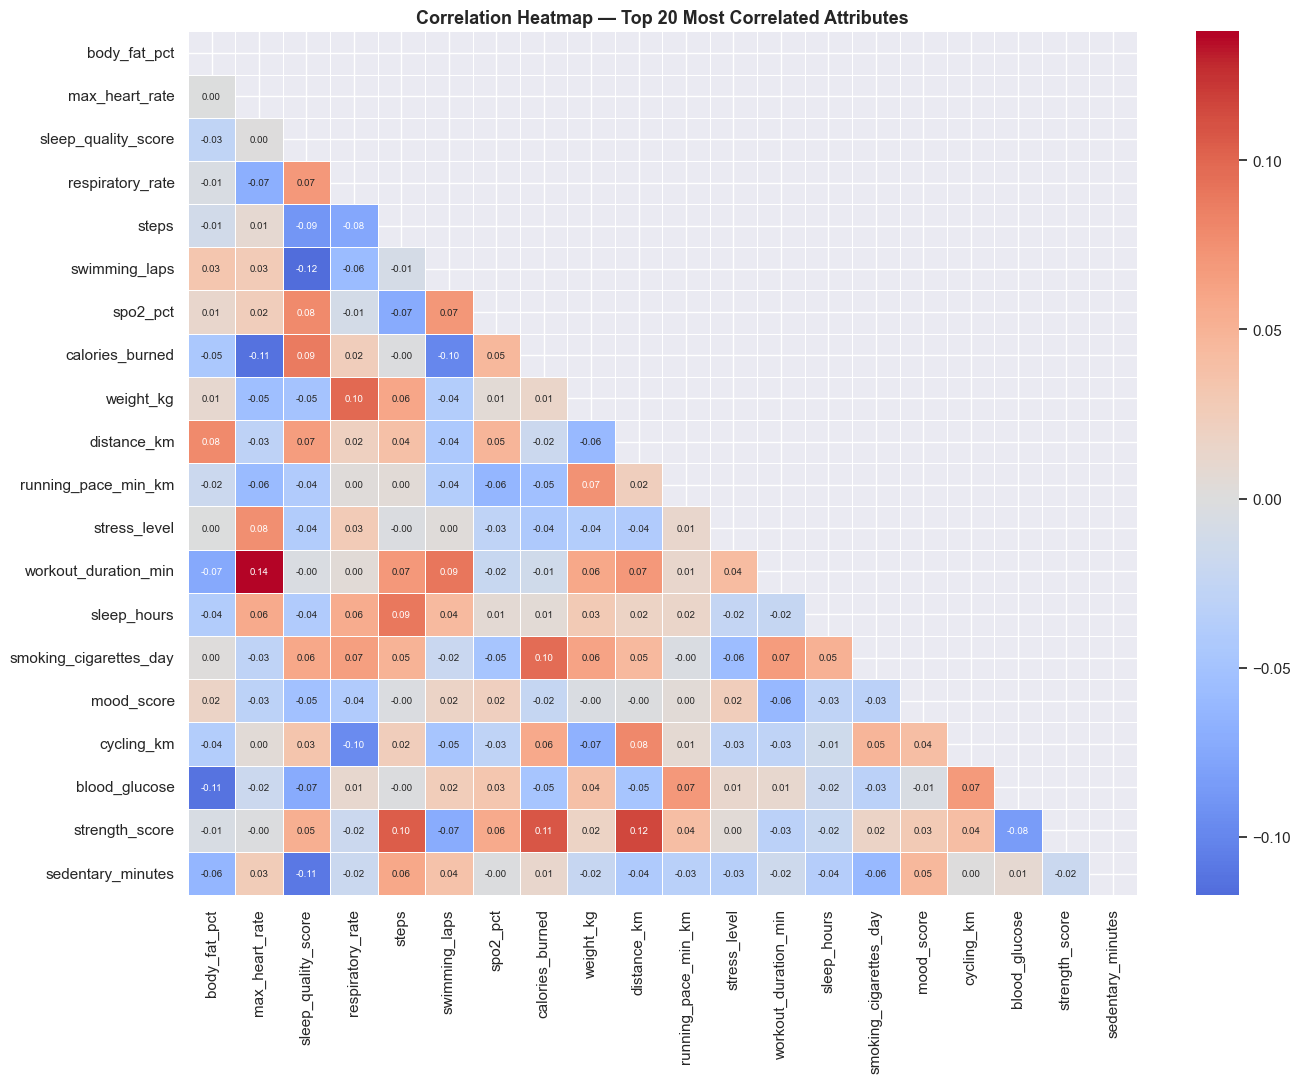

Saved: plot_3_correlation.png


<Figure size 1400x1200 with 0 Axes>

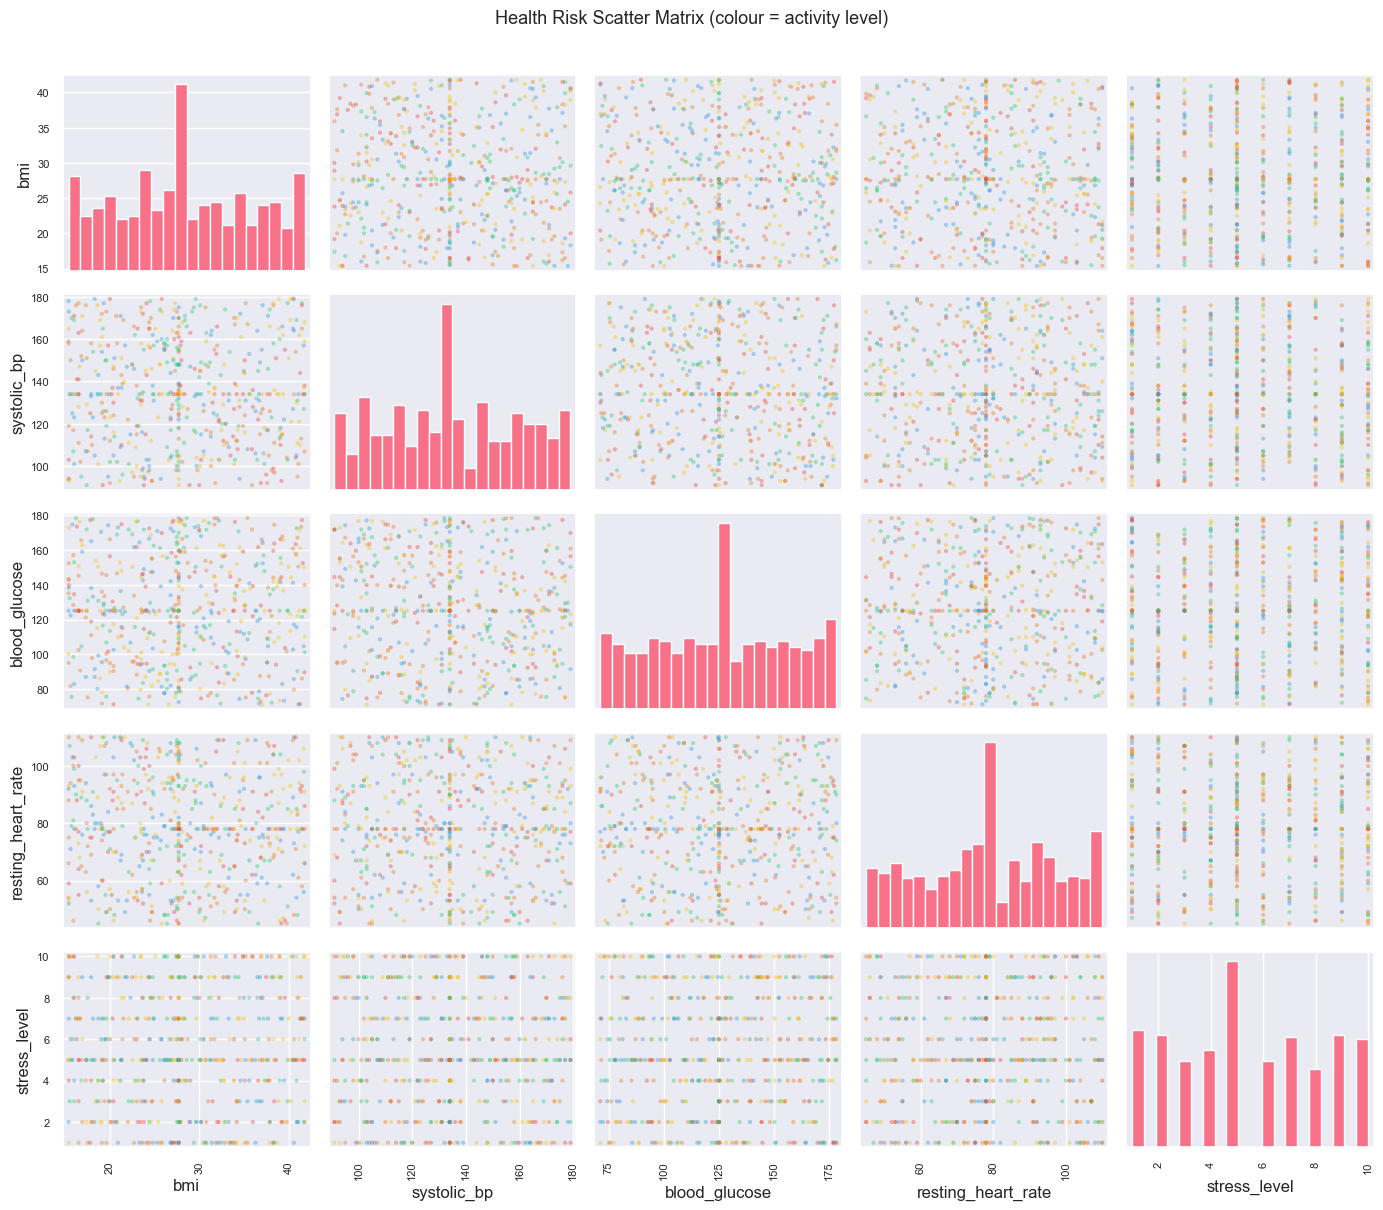

Saved: plot_4_scatter_matrix.png


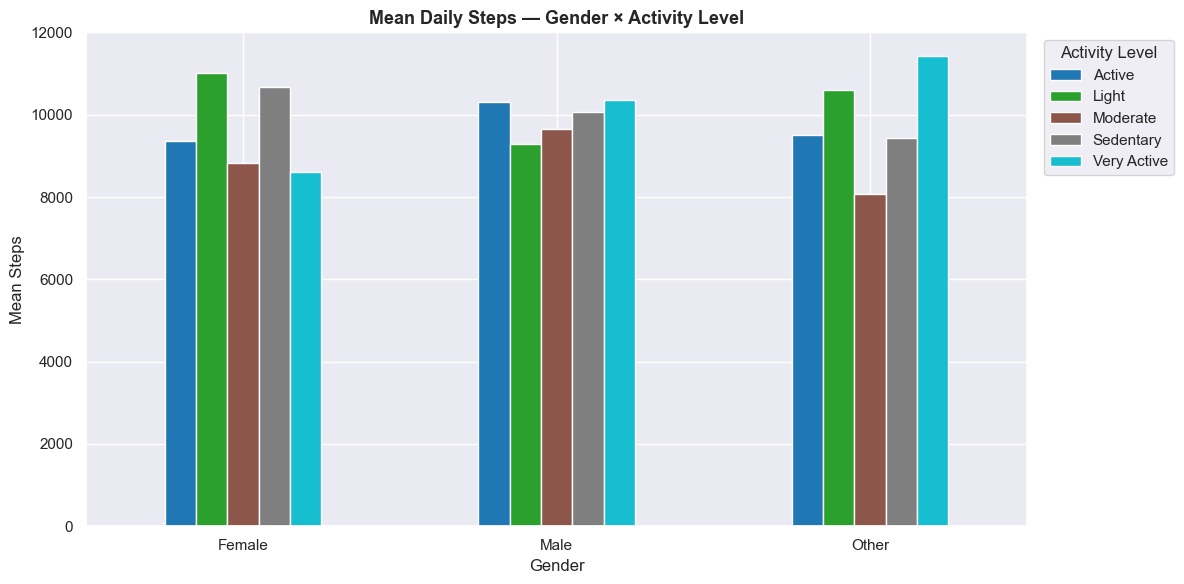

Saved: plot_5_grouped_bar.png


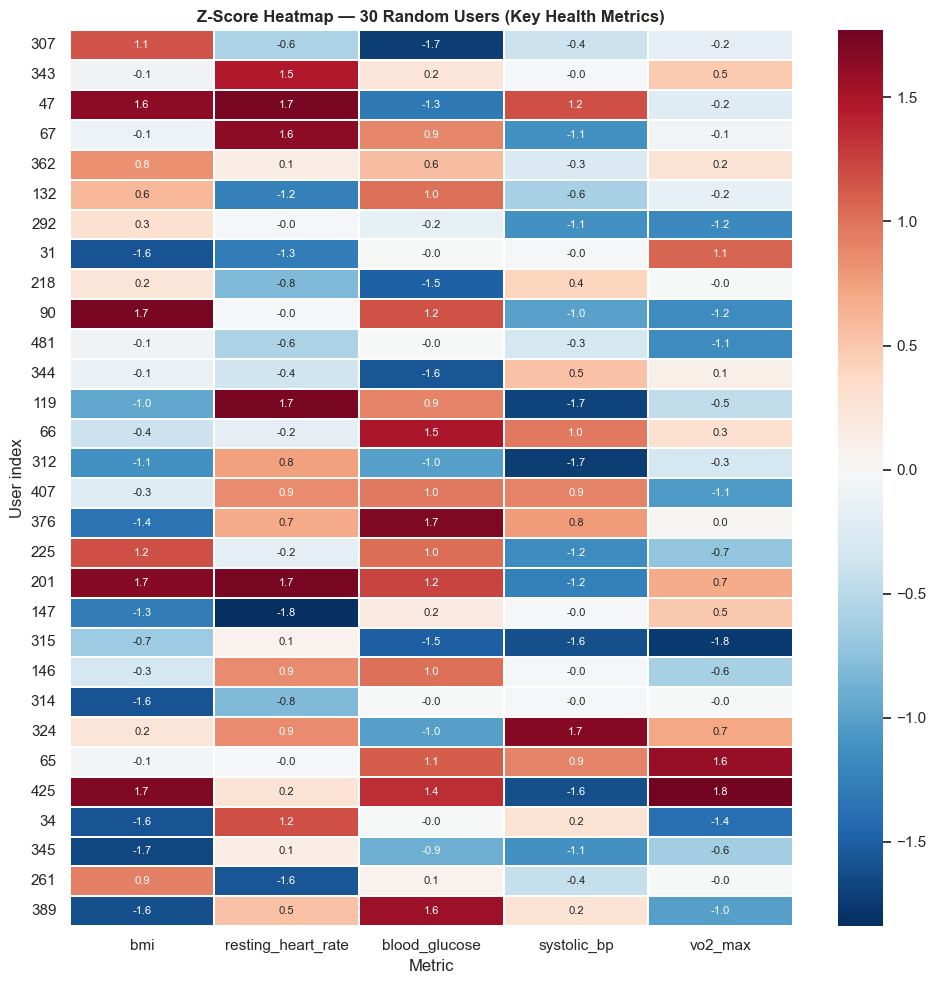

Saved: plot_6_zscore_heatmap.png

ALL DONE — 6 plots saved to your folder


In [32]:
#Section 7. Visualisations
print("\n" + "=" * 70)
print("SECTION 7 — GENERATING VISUALIZATIONS ...")
print("=" * 70)

PALETTE = "husl"
sns.set_theme(style="darkgrid", palette=PALETTE)

# ── Plot 1: Distribution Dashboard (key health metrics) ──────────
KEY_METRICS = ["steps", "sleep_hours", "bmi", "resting_heart_rate",
               "vo2_max", "stress_level", "calories_burned", "blood_glucose"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle("Distribution Dashboard — Key Health Metrics", fontsize=15, fontweight="bold", y=1.01)

for i, col in enumerate(KEY_METRICS):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=25, color=sns.color_palette(PALETTE, 8)[i], edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(),   color="red",    linestyle="--", linewidth=1.5, label=f"Mean {data.mean():.1f}")
    ax.axvline(data.median(), color="yellow", linestyle=":",  linewidth=1.5, label=f"Med {data.median():.1f}")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("plot_1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_1_distributions.png")

# ── Plot 2: Box plots by Activity Level ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Key Metrics by Activity Level", fontsize=14, fontweight="bold")

for ax, col in zip(axes, ["steps", "bmi", "vo2_max"]):
    order = ["Sedentary", "Light", "Moderate", "Active", "Very Active"]
    order = [o for o in order if o in df["activity_level"].unique()]
    sns.boxplot(data=df, x="activity_level", y=col, order=order, palette="Set2", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
    ax.set_title(col)

plt.tight_layout()
plt.savefig("plot_2_activity_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_2_activity_boxplots.png")

# ── Plot 3: Correlation heatmap (top 20 columns) ─────────────────
TOP20_COLS = (corr_pairs.groupby("var1")["abs_r"].max()
                         .sort_values(ascending=False)
                         .head(20).index.tolist())

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix.loc[TOP20_COLS, TOP20_COLS], dtype=bool))
sns.heatmap(corr_matrix.loc[TOP20_COLS, TOP20_COLS],
            annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.4, mask=mask, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Heatmap — Top 20 Most Correlated Attributes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_3_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_3_correlation.png")

# ── Plot 4: Scatter matrix (health risk cluster) ─────────────────
RISK_COLS = ["bmi", "systolic_bp", "blood_glucose", "resting_heart_rate", "stress_level"]
fig = plt.figure(figsize=(14, 12))
fig.suptitle("Health Risk Factor — Scatter Matrix", fontsize=14, fontweight="bold")

colors = df["activity_level"].map({
    "Sedentary": "#e74c3c", "Light": "#e67e22", "Moderate": "#f1c40f",
    "Active": "#2ecc71", "Very Active": "#3498db"
}).fillna("grey")

pd.plotting.scatter_matrix(df[RISK_COLS], figsize=(14, 12),
                            color=colors, alpha=0.4, diagonal="hist",
                            hist_kwds={"bins": 20})
plt.suptitle("Health Risk Scatter Matrix (colour = activity level)", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("plot_4_scatter_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_4_scatter_matrix.png")

# ── Plot 5: Grouped bar — mean steps by gender × activity level ──
pivot = df.groupby(["gender", "activity_level"])["steps"].mean().unstack()
pivot.plot(kind="bar", figsize=(12, 6), colormap="tab10", edgecolor="white")
plt.title("Mean Daily Steps — Gender × Activity Level", fontsize=13, fontweight="bold")
plt.ylabel("Mean Steps")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.legend(title="Activity Level", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig("plot_5_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_5_grouped_bar.png")

# ── Plot 6: Z-score heatmap (random 30 users, key cols) ──────────
sample_idx = df.sample(30, random_state=1).index
z_sample = z_scores.loc[sample_idx, KEY].round(2)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(z_sample, annot=True, fmt=".1f", cmap="RdBu_r",
            center=0, linewidths=0.3, ax=ax, annot_kws={"size": 8})
ax.set_title("Z-Score Heatmap — 30 Random Users (Key Health Metrics)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Metric")
ax.set_ylabel("User index")
plt.tight_layout()
plt.savefig("plot_6_zscore_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_6_zscore_heatmap.png")

print("\n" + "=" * 70)
print("ALL DONE — 6 plots saved to your folder")
print("=" * 70)
